In [133]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv(
    "../data/processed/weather_clean.csv",
    parse_dates=["timestamp"]
)

targets = [
    "temperature_c",
    "humidity_pct",
    "sea_level_pressure_hpa",
    "wind_speed_ms",
    "precipitation_mm"
]

## temperature analysis

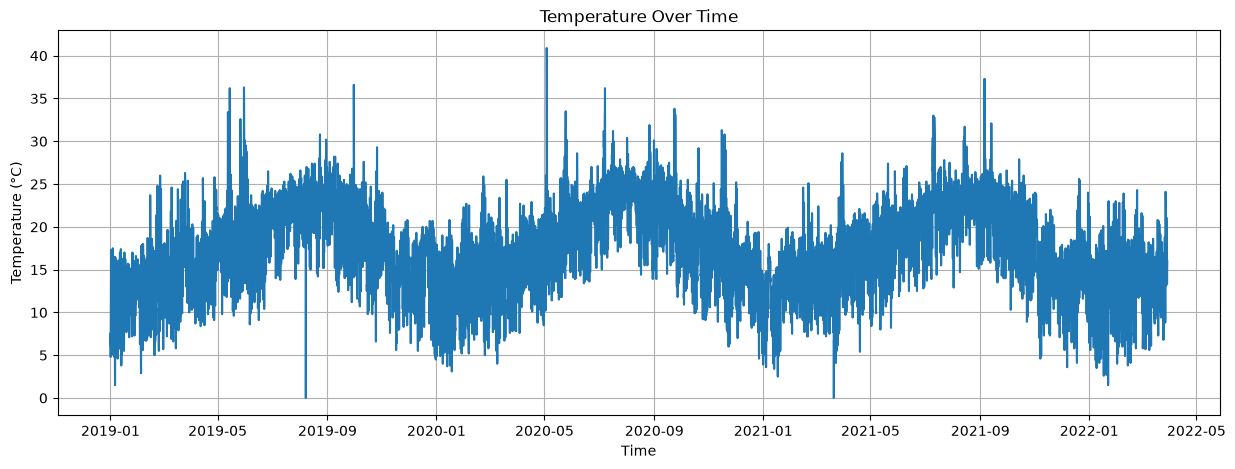

In [107]:
plt.figure(figsize=(15,5))

plt.plot(
    df["timestamp"],
    df["temperature_c"]
)

plt.title("Temperature Over Time")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.grid(True)

plt.show()

In [108]:
df[df["temperature_c"] <= 1][
    ["timestamp", "temperature_c"]
].head(20)

,timestamp,temperature_c
1732,2019-08-07 18:00:00,0.0
6412,2021-03-21 00:00:00,0.0


In [109]:
for idx in [1732, 6412]:
    print("\n")
    print(df.loc[idx-3:idx+3,
                 ["timestamp", "temperature_c"]])



               timestamp  temperature_c
1729 2019-08-07 09:00:00           23.7
1730 2019-08-07 12:00:00           25.1
1731 2019-08-07 15:00:00           25.8
1732 2019-08-07 18:00:00            0.0
1733 2019-08-07 21:00:00           22.1
1734 2019-08-08 00:00:00           22.3
1735 2019-08-08 03:00:00           19.1


               timestamp  temperature_c
6409 2021-03-20 15:00:00           15.1
6410 2021-03-20 18:00:00           12.7
6411 2021-03-20 21:00:00            9.5
6412 2021-03-21 00:00:00            0.0
6413 2021-03-21 03:00:00            6.7
6414 2021-03-21 06:00:00            6.4
6415 2021-03-21 09:00:00           13.0


In [110]:
df.loc[df["temperature_c"] == 0,
       "temperature_c"] = np.nan

df["temperature_c"] = (
    df["temperature_c"]
      .interpolate(method="linear")
)

## humidity analysis

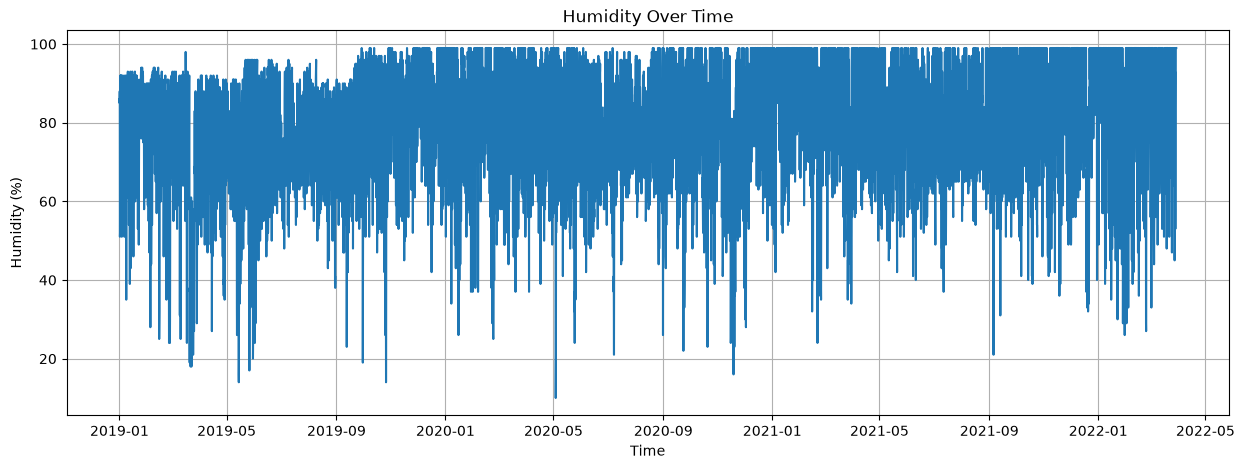

In [111]:
plt.figure(figsize=(15,5))

plt.plot(
    df["timestamp"],
    df["humidity_pct"]
)

plt.title("Humidity Over Time")
plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.grid(True)

plt.show()

In [112]:
print("Min humidity:", df["humidity_pct"].min())
print("Max humidity:", df["humidity_pct"].max())

Min humidity: 10.0
Max humidity: 99.0


## sea level analysis

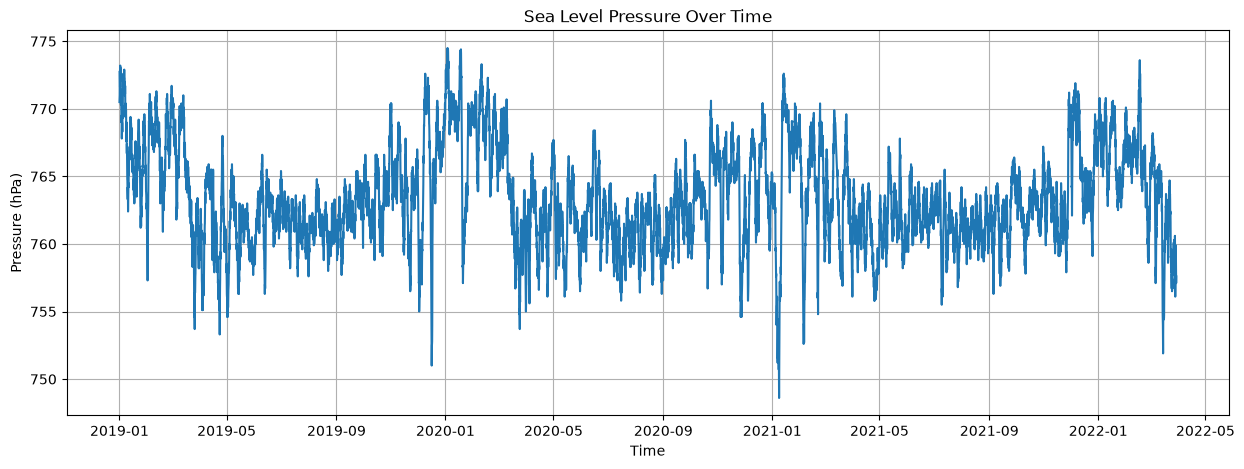

In [113]:
plt.figure(figsize=(15,5))

plt.plot(
    df["timestamp"],
    df["sea_level_pressure_hpa"]
)

plt.title("Sea Level Pressure Over Time")
plt.xlabel("Time")
plt.ylabel("Pressure (hPa)")
plt.grid(True)

plt.show()

In [114]:
print(df["sea_level_pressure_hpa"].min())
print(df["sea_level_pressure_hpa"].max())

748.6
774.5


## wind speed

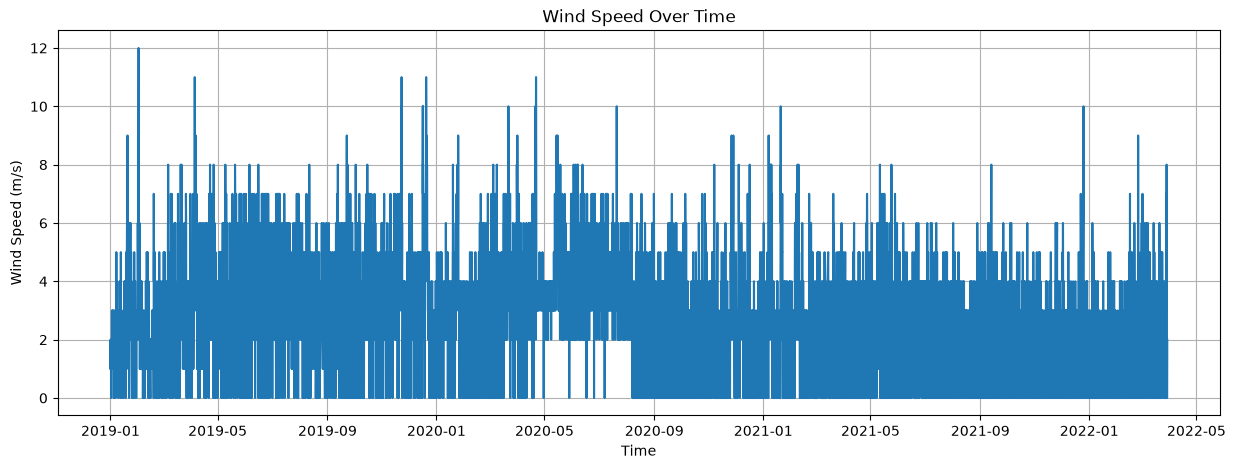

In [115]:
plt.figure(figsize=(15,5))

plt.plot(
    df["timestamp"],
    df["wind_speed_ms"]
)

plt.title("Wind Speed Over Time")
plt.xlabel("Time")
plt.ylabel("Wind Speed (m/s)")
plt.grid(True)

plt.show()

In [116]:
print("Min:", df["wind_speed_ms"].min())
print("Max:", df["wind_speed_ms"].max())
print("Mean:", df["wind_speed_ms"].mean())

Min: 0.0
Max: 12.0
Mean: 2.6139267461669506


## precipitation

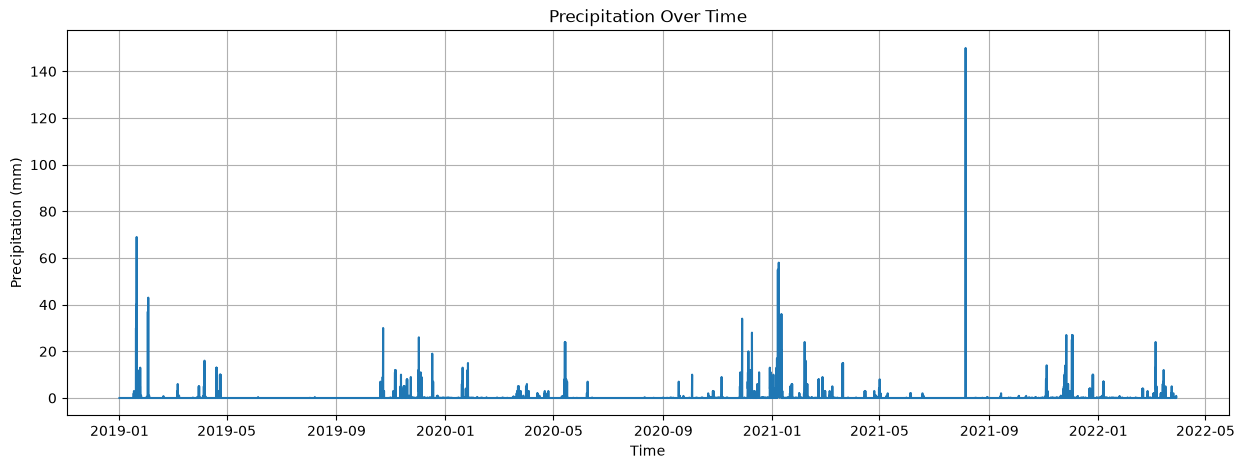

In [117]:
plt.figure(figsize=(15,5))

plt.plot(
    df["timestamp"],
    df["precipitation_mm"]
)

plt.title("Precipitation Over Time")
plt.xlabel("Time")
plt.ylabel("Precipitation (mm)")
plt.grid(True)

plt.show()

In [118]:
print("Min:", df["precipitation_mm"].min())
print("Max:", df["precipitation_mm"].max())

print("\nNumber of rainy observations:")
print((df["precipitation_mm"] > 0).sum())

print("\nPercentage rainy:")
print(
    (df["precipitation_mm"] > 0).mean() * 100
)

Min: 0.0
Max: 150.0

Number of rainy observations:
1241

Percentage rainy:
13.2133730834753


## correltion matrix

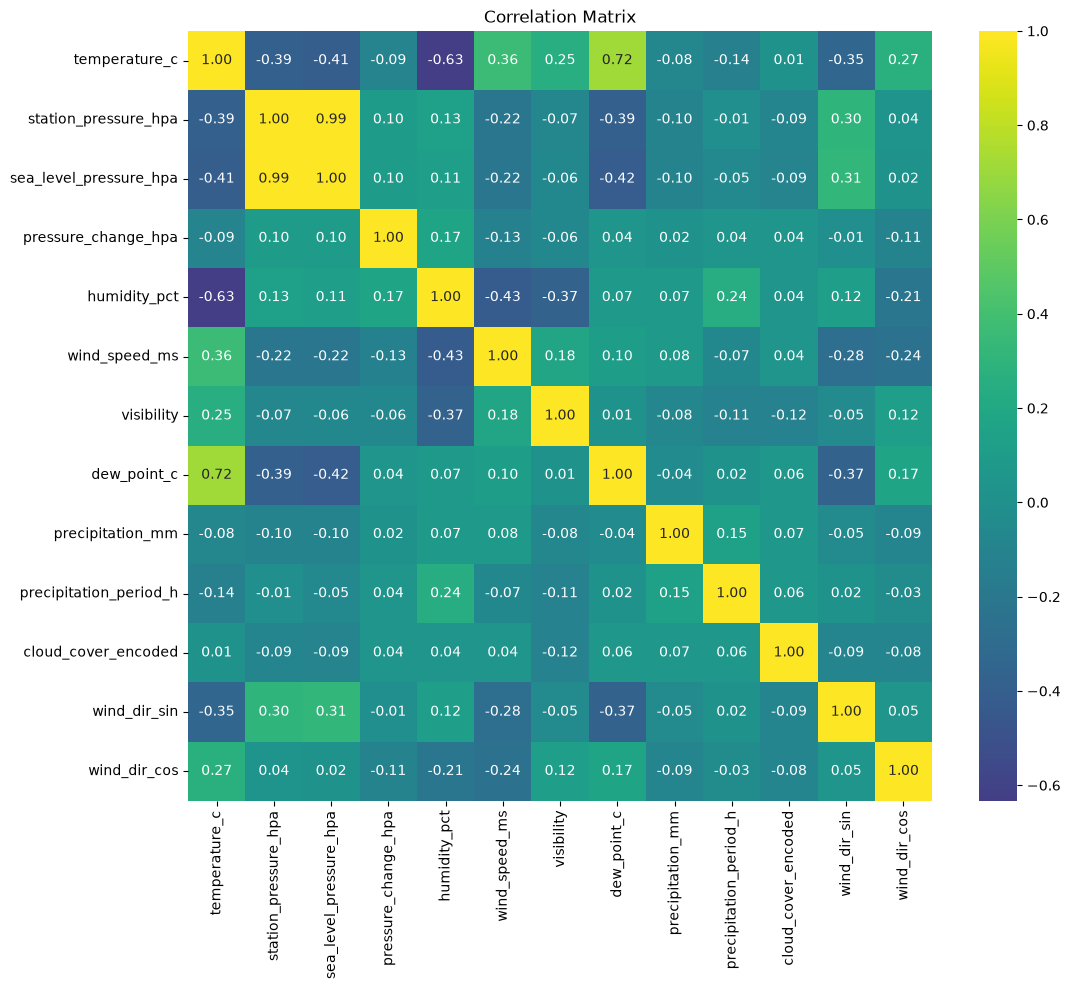

In [119]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.drop(columns=["timestamp"]).corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,
    cmap="viridis",
    center=0,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

## stationarity tests

In [120]:
import numpy as np
import scipy
import statsmodels

print("numpy:", np.__version__)
print("scipy:", scipy.__version__)
print("statsmodels:", statsmodels.__version__)

numpy: 2.4.6
scipy: 1.18.0
statsmodels: 0.14.6


In [121]:
from scipy.signal import correlate

In [122]:
targets = [
    "temperature_c",
    "humidity_pct",
    "sea_level_pressure_hpa",
    "wind_speed_ms",
    "precipitation_mm"
]

In [123]:
from statsmodels.tsa.stattools import adfuller, kpss

def stationarity_tests(series, name):

    adf_result = adfuller(series)

    try:
        kpss_result = kpss(series, regression="c", nlags="auto")
        kpss_p = kpss_result[1]
    except:
        kpss_p = None

    print(f"\n{name}")
    print("-" * 40)
    print(f"ADF p-value : {adf_result[1]:.6f}")

    if kpss_p is not None:
        print(f"KPSS p-value: {kpss_p:.6f}")
    else:
        print("KPSS failed")

In [124]:
for col in [
    "temperature_c",
    "humidity_pct",
    "sea_level_pressure_hpa",
    "wind_speed_ms",
    "precipitation_mm"
]:
    stationarity_tests(df[col], col)


temperature_c
----------------------------------------
ADF p-value : 0.000597
KPSS p-value: 0.026492


C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_2336\1316964852.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series, regression="c", nlags="auto")



humidity_pct
----------------------------------------
ADF p-value : 0.000000
KPSS p-value: 0.010000


C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_2336\1316964852.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series, regression="c", nlags="auto")



sea_level_pressure_hpa
----------------------------------------
ADF p-value : 0.000000
KPSS p-value: 0.100000


C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_2336\1316964852.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series, regression="c", nlags="auto")



wind_speed_ms
----------------------------------------
ADF p-value : 0.000000
KPSS p-value: 0.010000

precipitation_mm
----------------------------------------
ADF p-value : 0.000000
KPSS p-value: 0.100000


C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_2336\1316964852.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series, regression="c", nlags="auto")


In [125]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

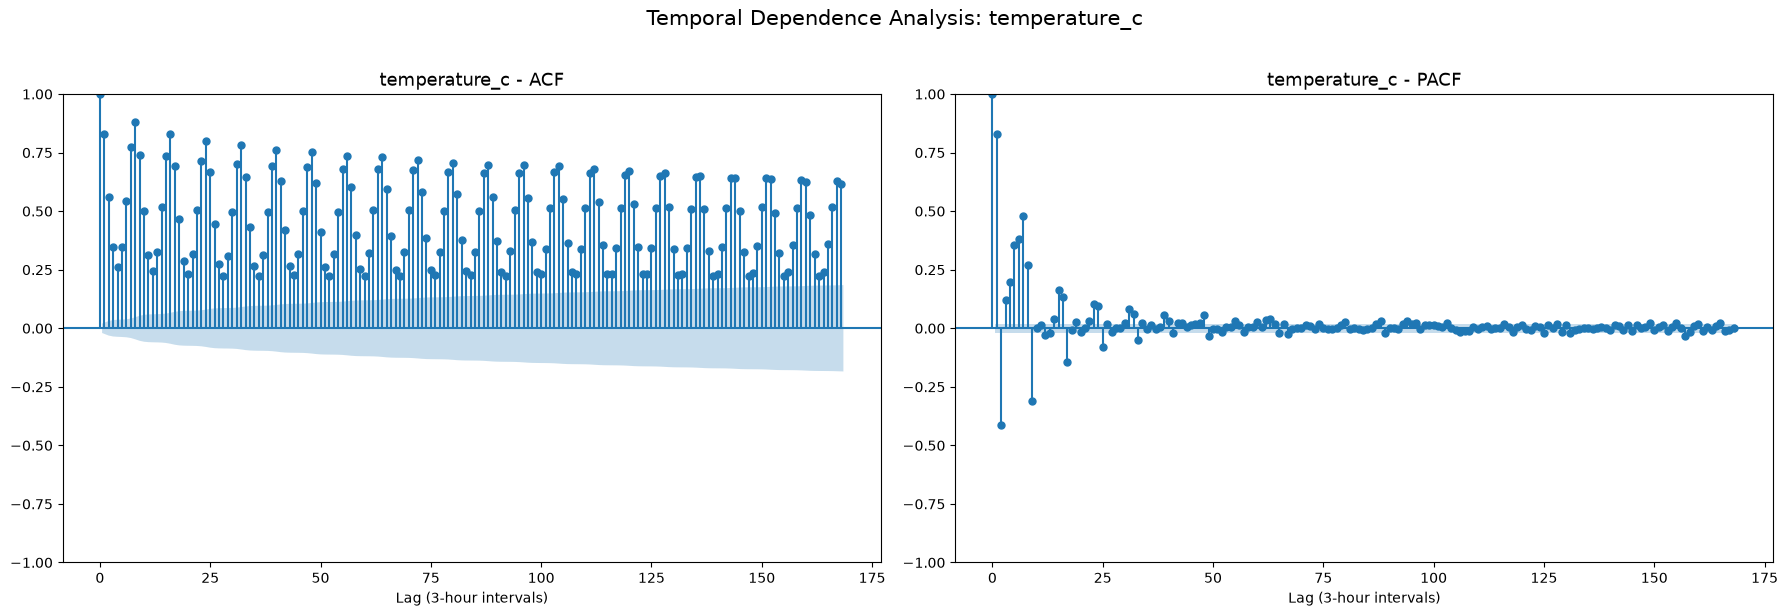

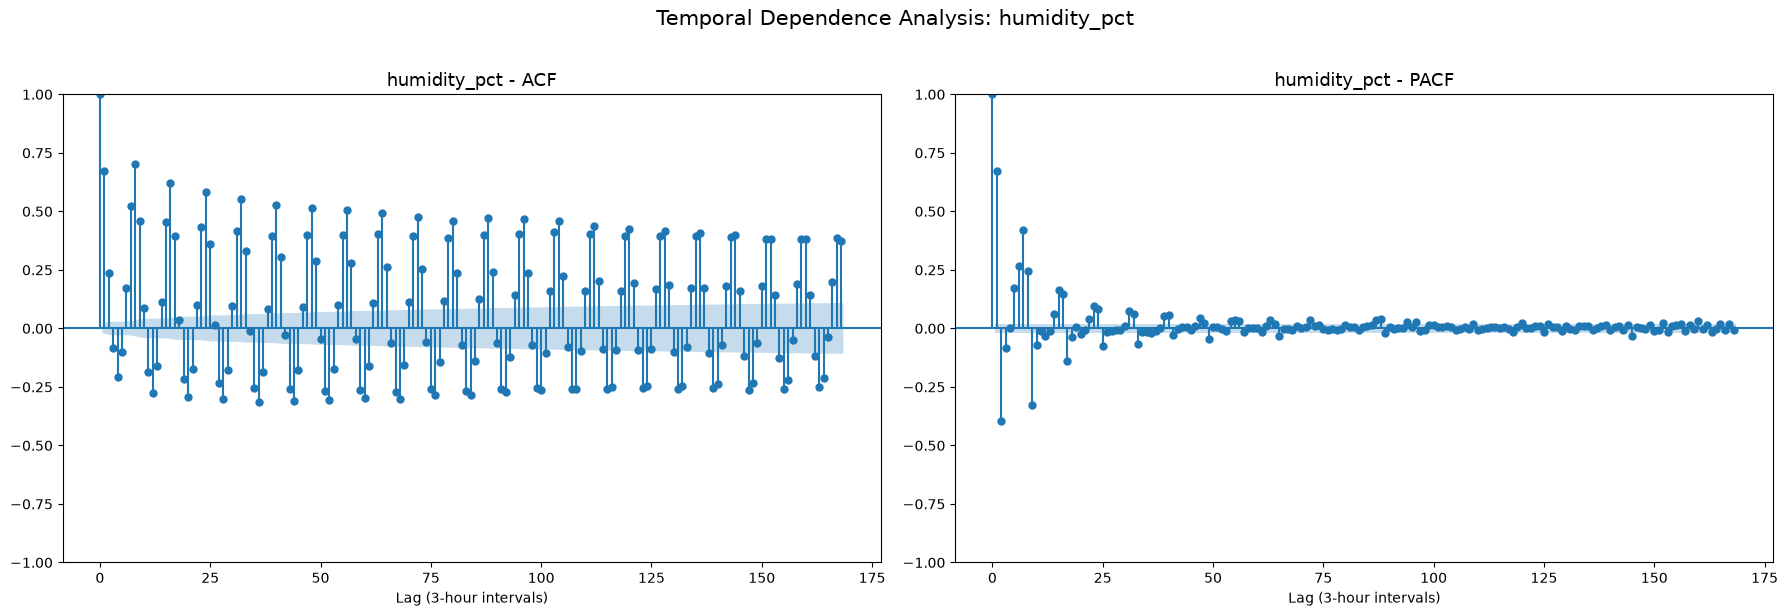

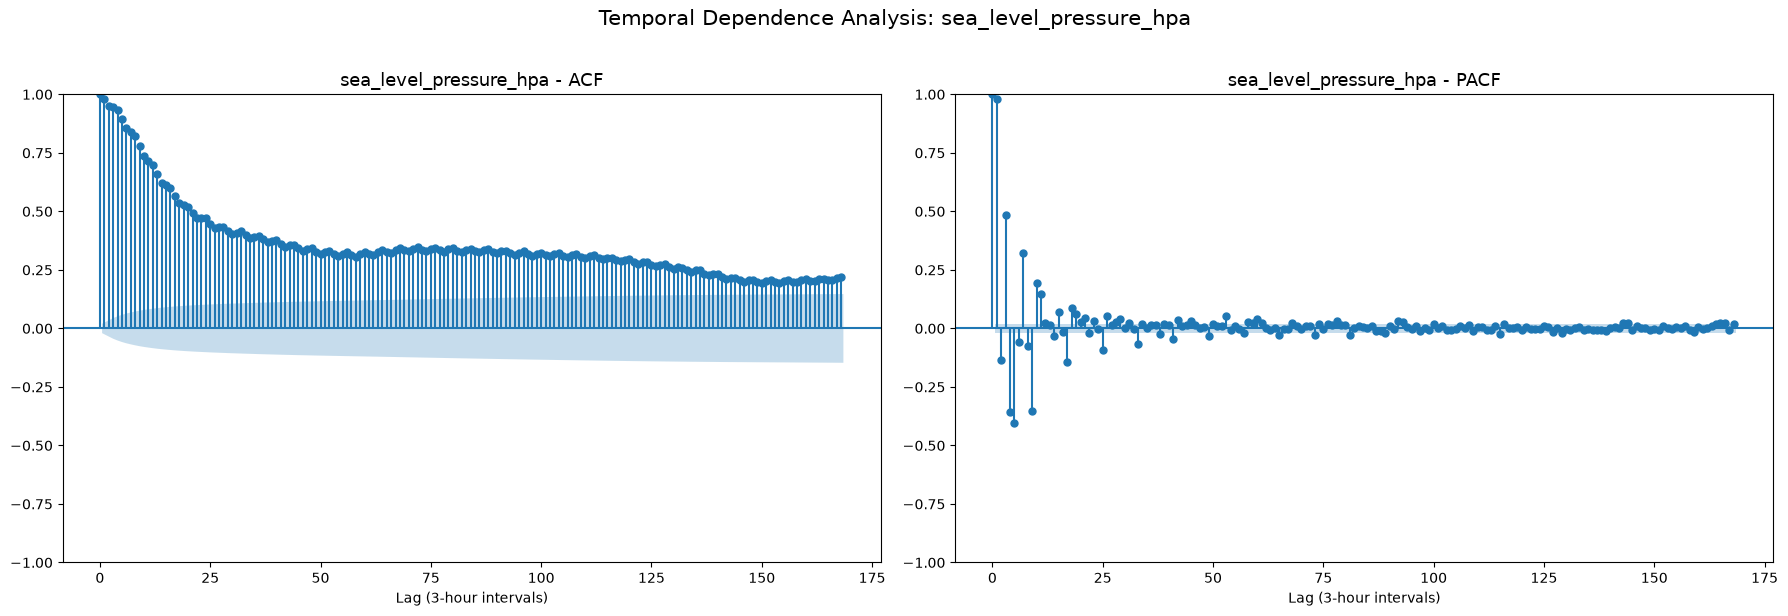

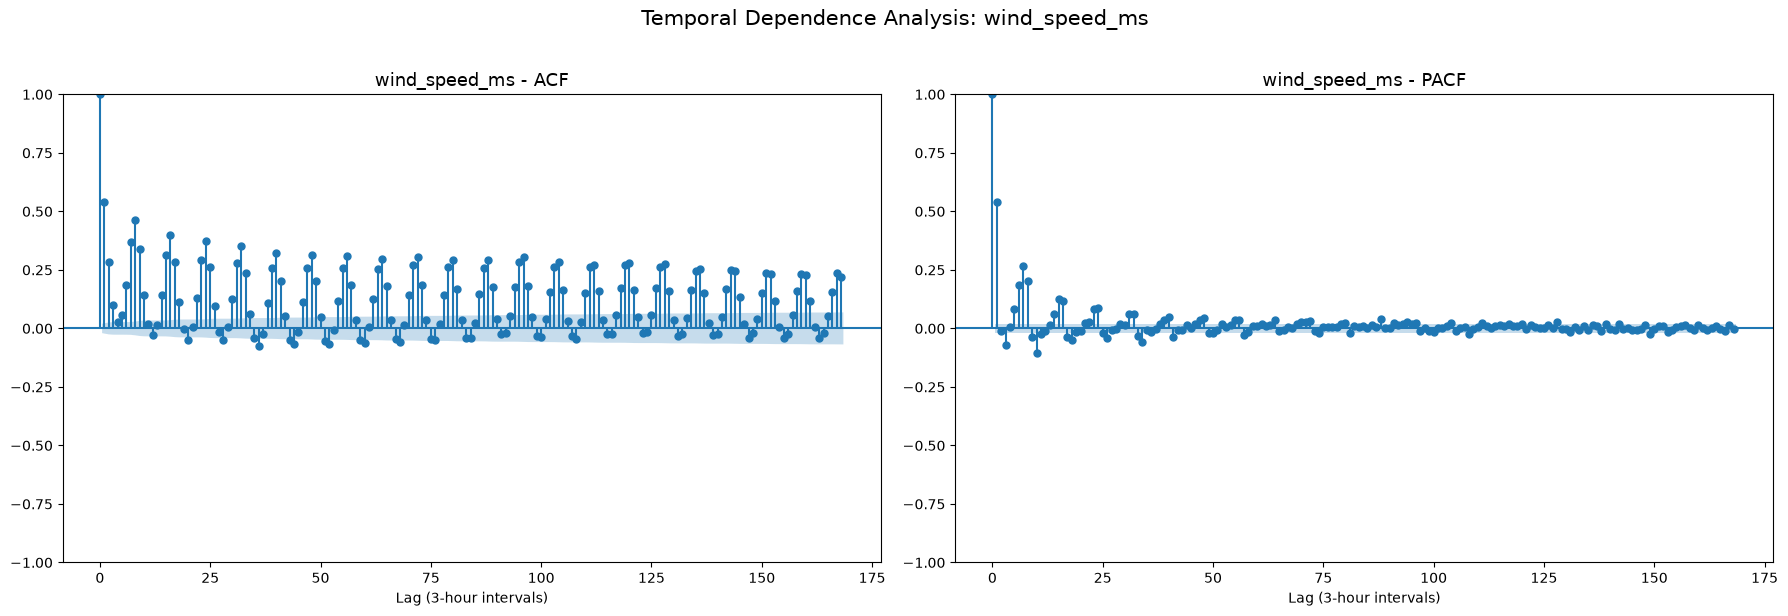

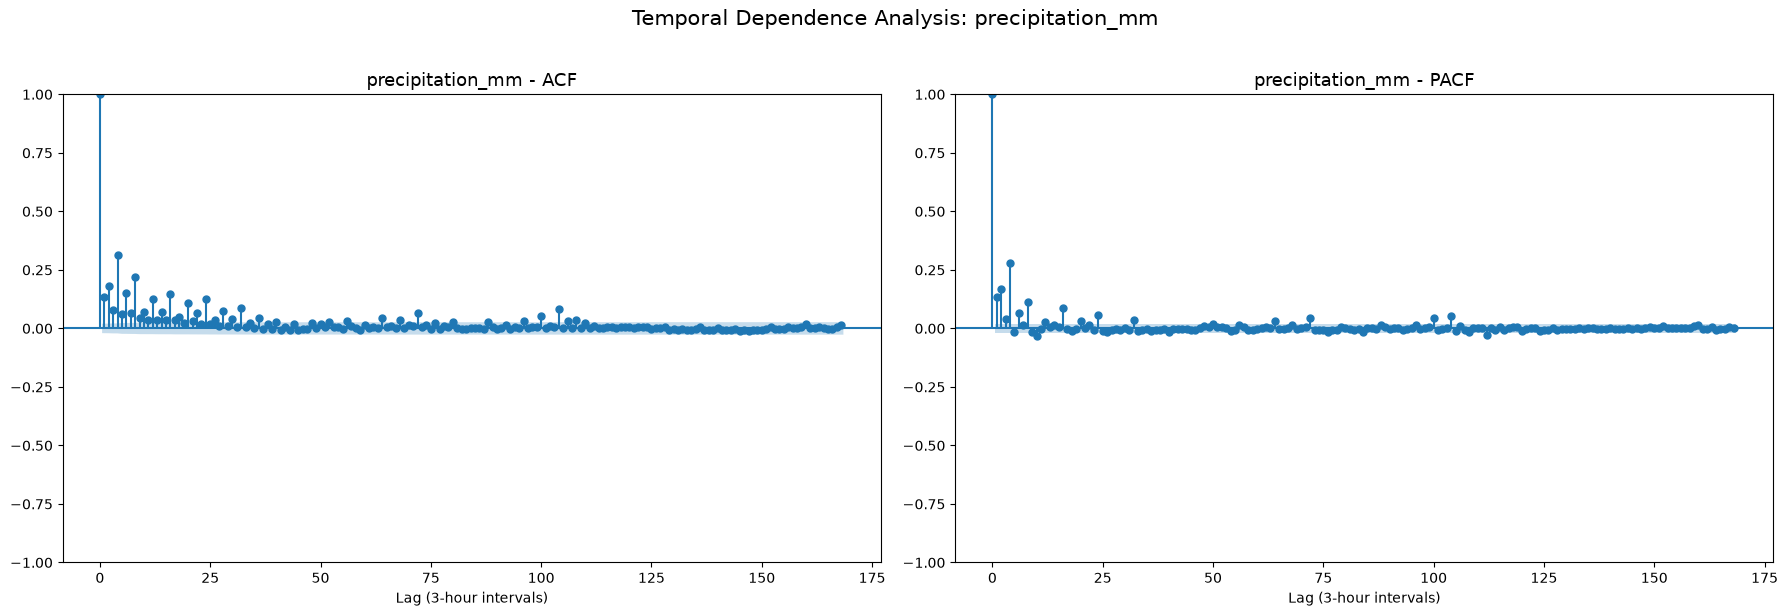

In [126]:
for col in targets:

    fig, axes = plt.subplots(
        1, 2,
        figsize=(18, 6)
    )

    plot_acf(
        df[col],
        lags=168,
        ax=axes[0],
        alpha=0.05
    )

    plot_pacf(
        df[col],
        lags=168,
        ax=axes[1],
        alpha=0.05,
        method="ywm"
    )

    axes[0].set_title(
        f"{col} - ACF",
        fontsize=13
    )

    axes[1].set_title(
        f"{col} - PACF",
        fontsize=13
    )

    axes[0].set_xlabel("Lag (3-hour intervals)")
    axes[1].set_xlabel("Lag (3-hour intervals)")

    plt.suptitle(
        f"Temporal Dependence Analysis: {col}",
        fontsize=15,
        y=1.02
    )

    plt.tight_layout()
    plt.show()

## fft

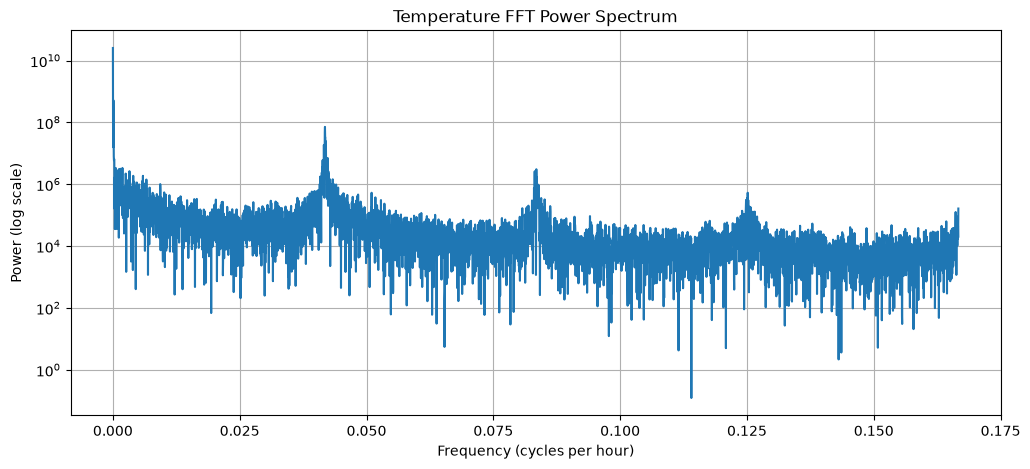

In [127]:
import numpy as np
import matplotlib.pyplot as plt

signal = df["temperature_c"].values

fft_vals = np.fft.rfft(signal)

power = np.abs(fft_vals) ** 2

freqs = np.fft.rfftfreq(
    len(signal),
    d=3  # 3 hours between observations
)

plt.figure(figsize=(12,5))
plt.plot(freqs, power)

plt.yscale("log")

plt.title("Temperature FFT Power Spectrum")
plt.xlabel("Frequency (cycles per hour)")
plt.ylabel("Power (log scale)")
plt.grid(True)

plt.show()

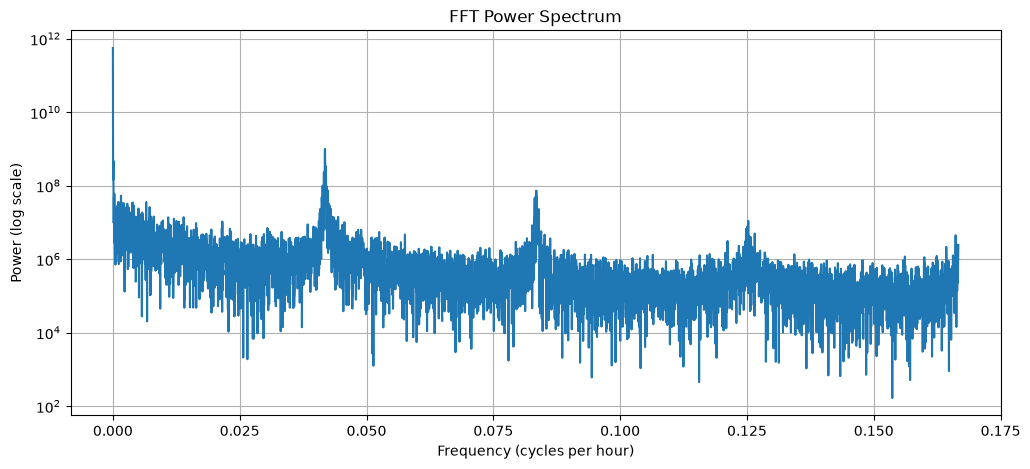

In [128]:
import numpy as np
import matplotlib.pyplot as plt

signal = df["humidity_pct"].values

fft_vals = np.fft.rfft(signal)

power = np.abs(fft_vals)**2

freqs = np.fft.rfftfreq(
    len(signal),
    d=3
)

plt.figure(figsize=(12,5))

plt.plot(freqs, power)

plt.yscale("log")

plt.title("FFT Power Spectrum")
plt.xlabel("Frequency (cycles per hour)")
plt.ylabel("Power (log scale)")

plt.grid(True)

plt.show()

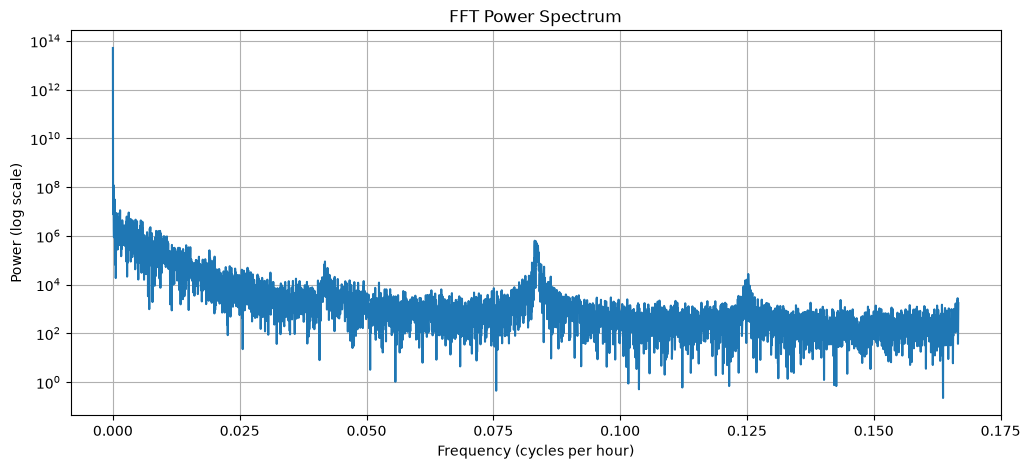

In [129]:
import numpy as np
import matplotlib.pyplot as plt

signal = df["sea_level_pressure_hpa"].values

fft_vals = np.fft.rfft(signal)

power = np.abs(fft_vals)**2

freqs = np.fft.rfftfreq(
    len(signal),
    d=3
)

plt.figure(figsize=(12,5))

plt.plot(freqs, power)

plt.yscale("log")

plt.title("FFT Power Spectrum")
plt.xlabel("Frequency (cycles per hour)")
plt.ylabel("Power (log scale)")

plt.grid(True)

plt.show()

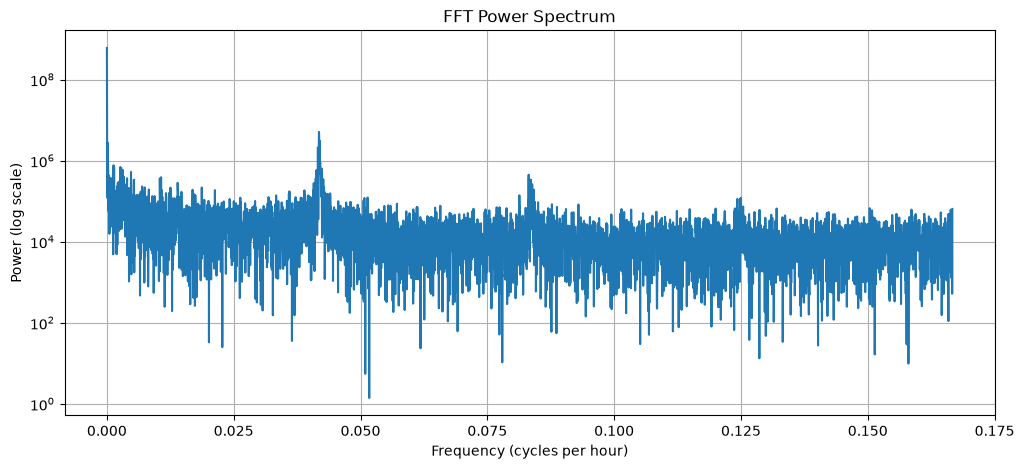

In [130]:
import numpy as np
import matplotlib.pyplot as plt

signal = df["wind_speed_ms"].values

fft_vals = np.fft.rfft(signal)

power = np.abs(fft_vals)**2

freqs = np.fft.rfftfreq(
    len(signal),
    d=3
)

plt.figure(figsize=(12,5))

plt.plot(freqs, power)

plt.yscale("log")

plt.title("FFT Power Spectrum")
plt.xlabel("Frequency (cycles per hour)")
plt.ylabel("Power (log scale)")

plt.grid(True)

plt.show()

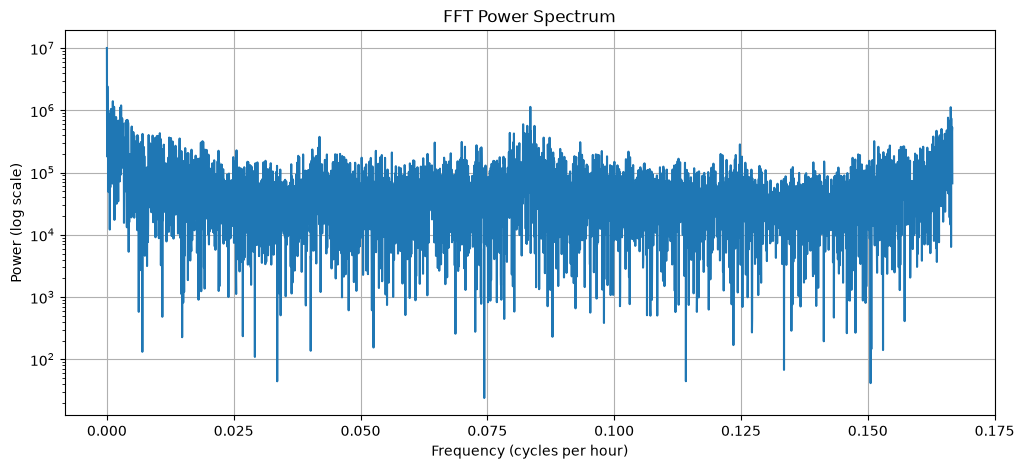

In [131]:
import numpy as np
import matplotlib.pyplot as plt

signal = df["precipitation_mm"].values

fft_vals = np.fft.rfft(signal)

power = np.abs(fft_vals)**2

freqs = np.fft.rfftfreq(
    len(signal),
    d=3
)

plt.figure(figsize=(12,5))

plt.plot(freqs, power)

plt.yscale("log")

plt.title("FFT Power Spectrum")
plt.xlabel("Frequency (cycles per hour)")
plt.ylabel("Power (log scale)")

plt.grid(True)

plt.show()

## Wavelet decomposition

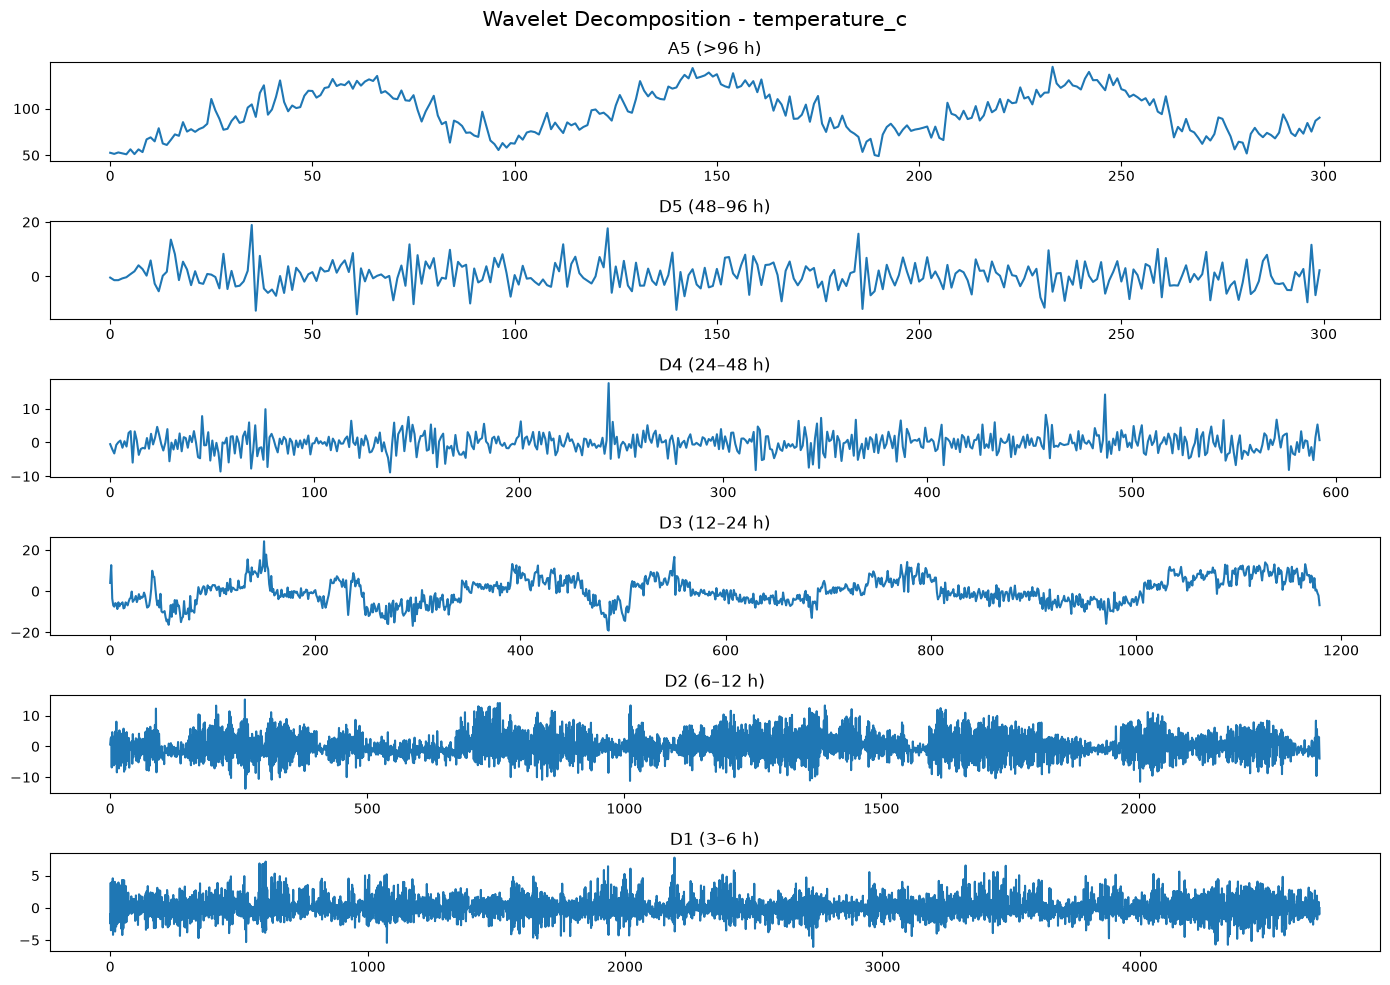

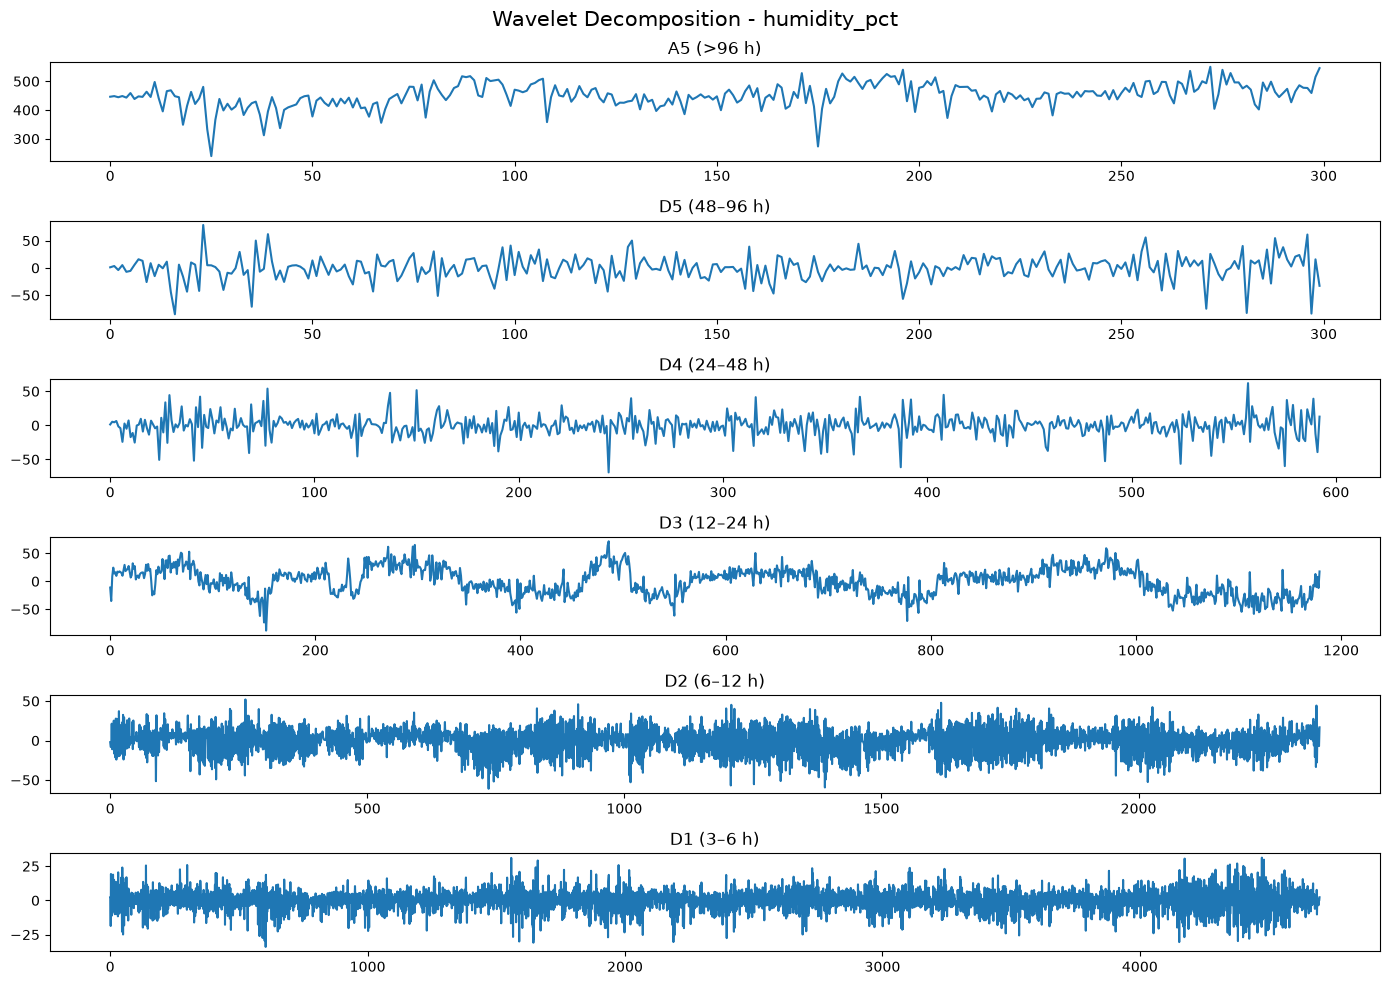

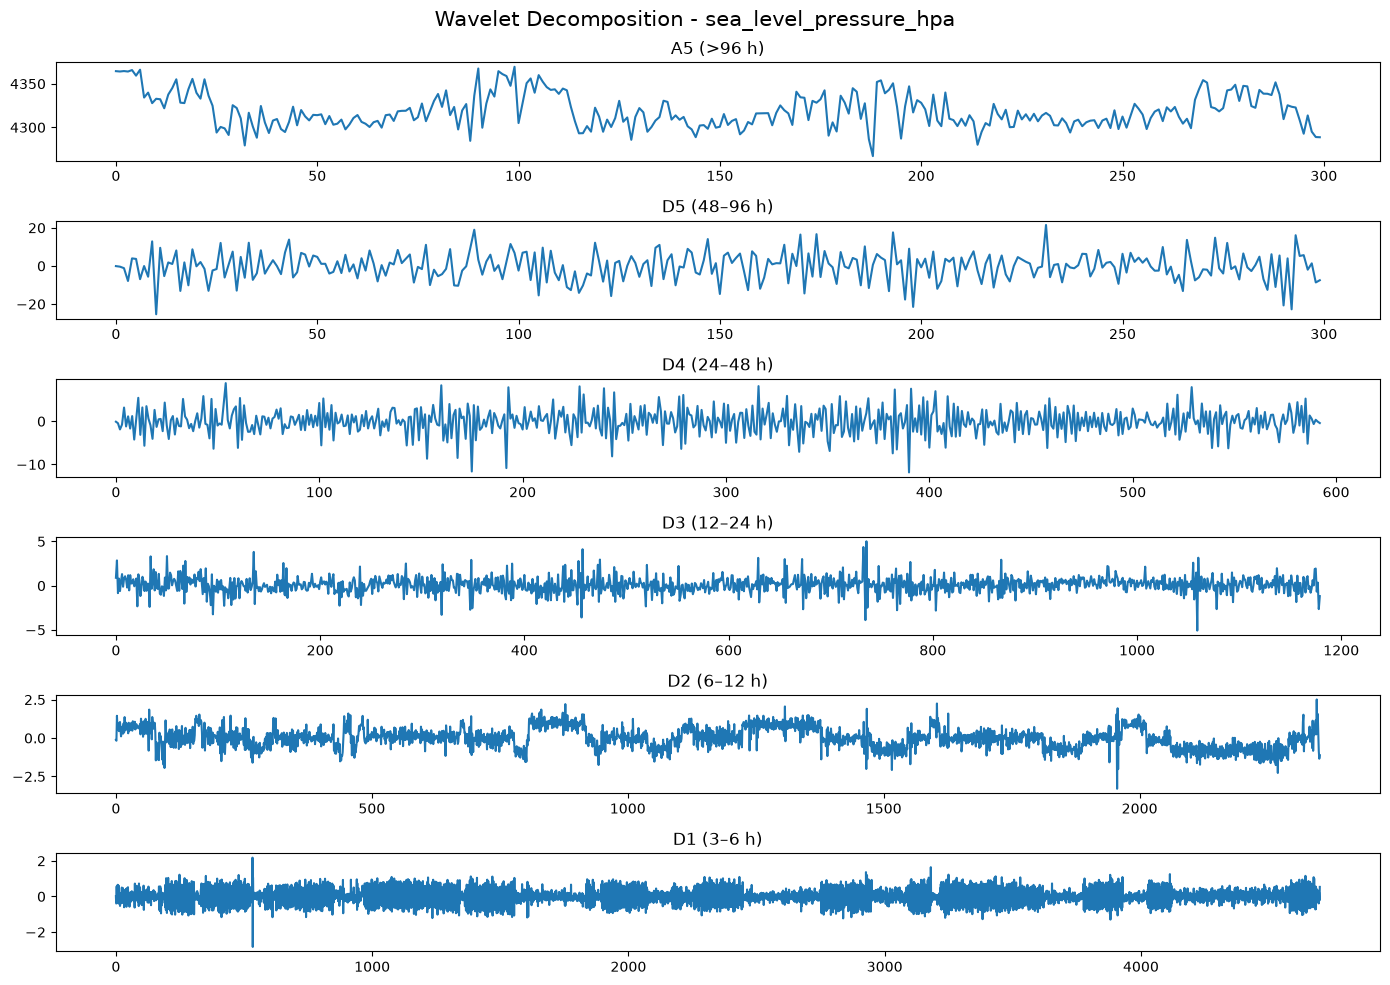

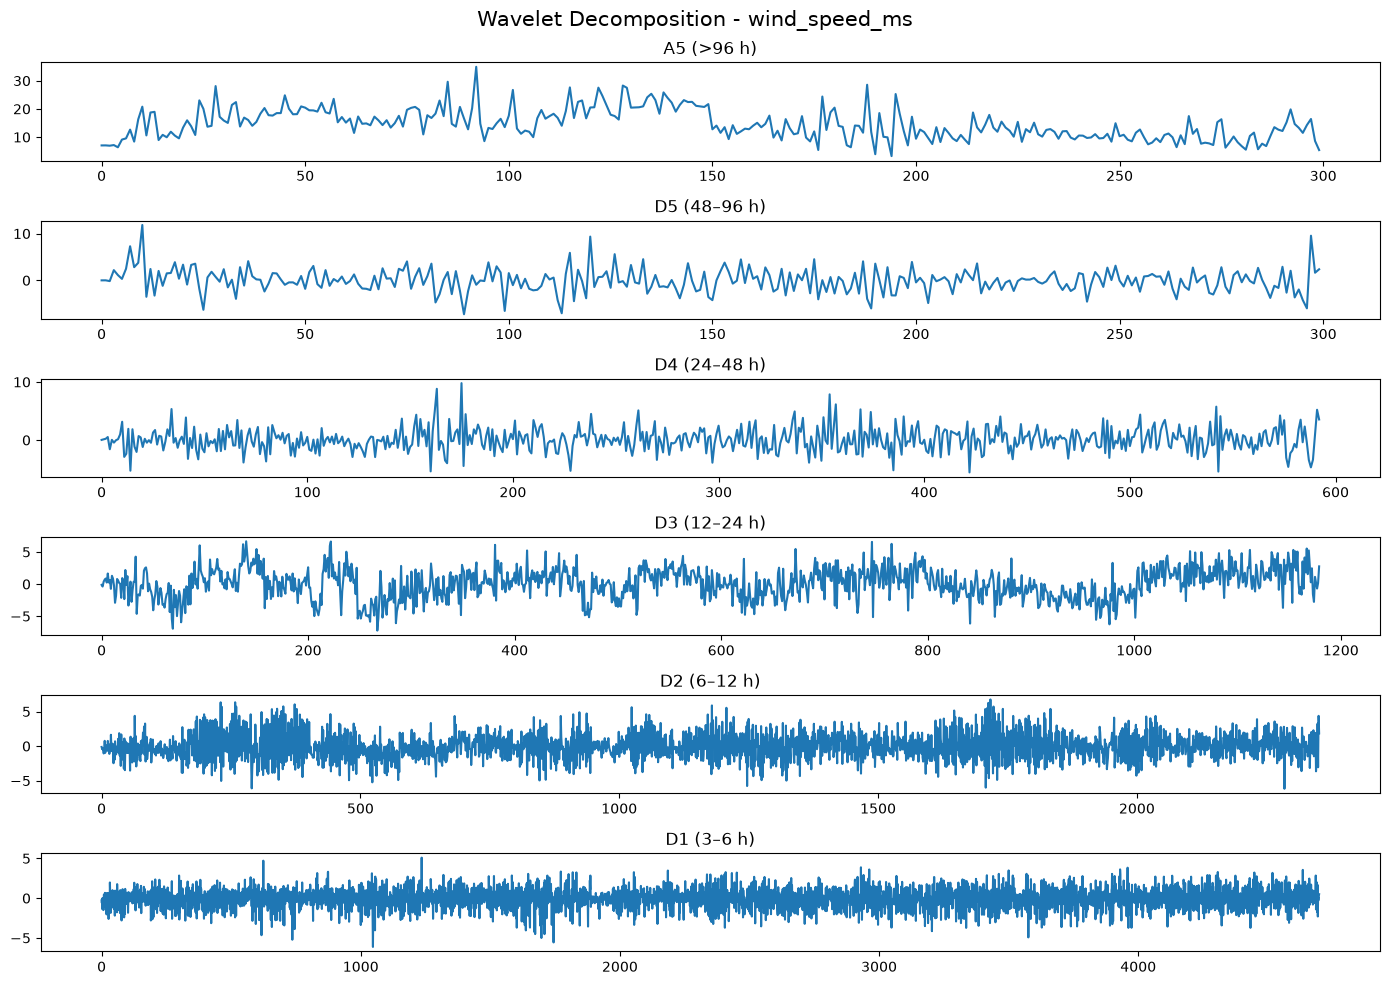

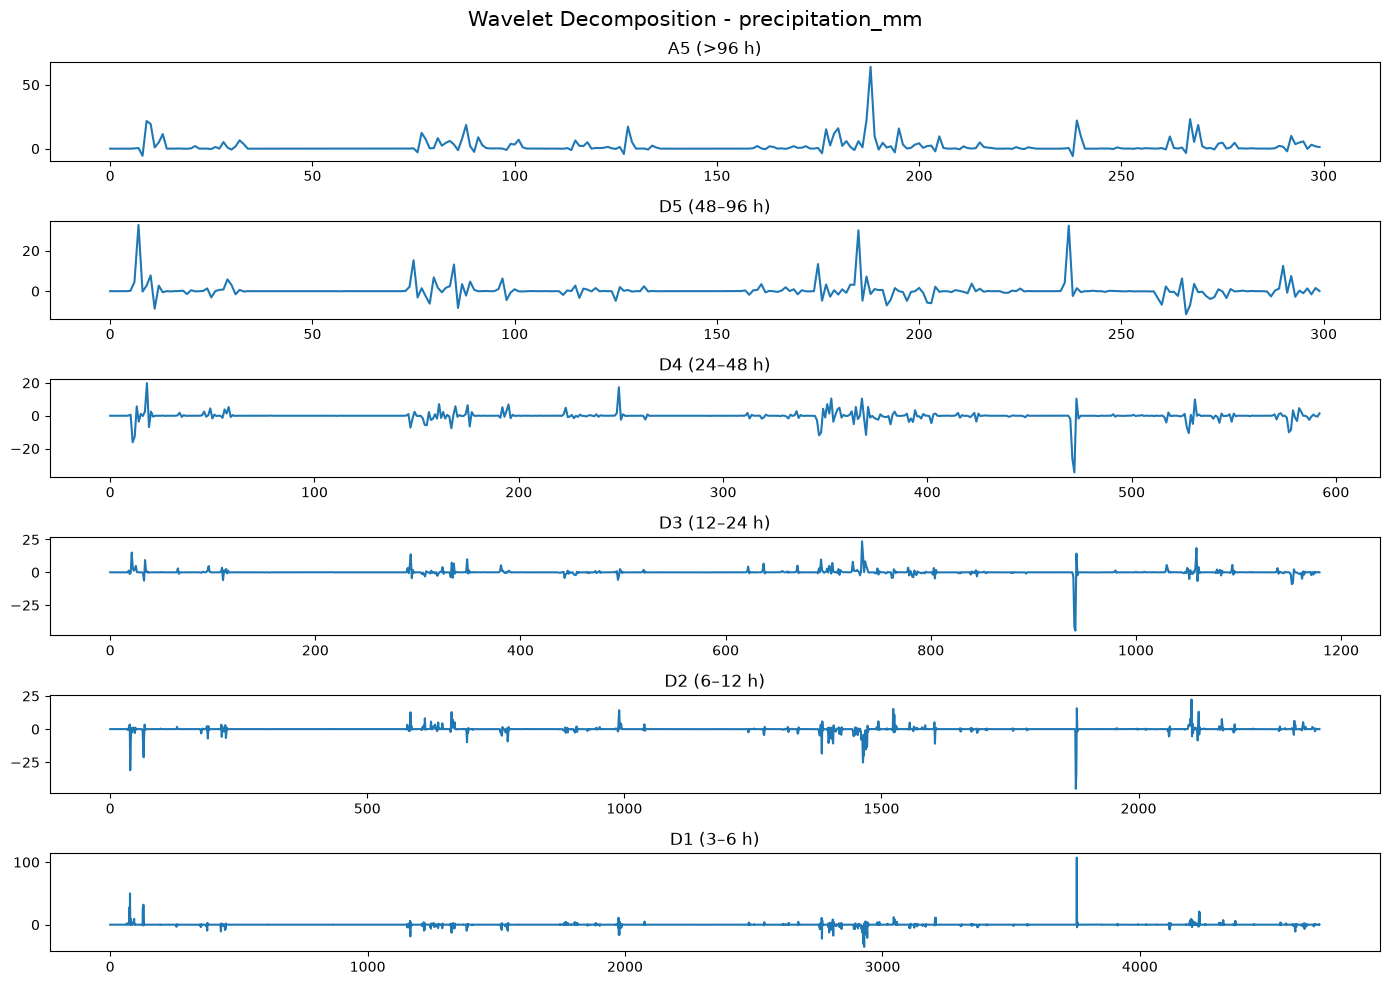

In [132]:
import pywt
import matplotlib.pyplot as plt
import numpy as np

targets = [
    "temperature_c",
    "humidity_pct",
    "sea_level_pressure_hpa",
    "wind_speed_ms",
    "precipitation_mm"
]

for col in targets:

    signal = df[col].to_numpy().copy()

    coeffs = pywt.wavedec(
        signal,
        wavelet="db4",
        level=5
    )

    fig, axes = plt.subplots(
        len(coeffs),
        1,
        figsize=(14, 10)
    )

    labels = [
        "A5 (>96 h)",
        "D5 (48–96 h)",
        "D4 (24–48 h)",
        "D3 (12–24 h)",
        "D2 (6–12 h)",
        "D1 (3–6 h)"
    ]

    for i, coeff in enumerate(coeffs):
        axes[i].plot(coeff)
        axes[i].set_title(labels[i])

    plt.suptitle(
        f"Wavelet Decomposition - {col}",
        fontsize=15
    )

    plt.tight_layout()
    plt.show()